# Phase 3.1 — Feature Alignment & Integration

**Goal:** Align behavioral and NLP features into a unified matrix ready for fusion.

## Overview
- **Behavioral features**: CRT, NFC, education, political affiliation, social media usage, news literacy
- **NLP features**: TF-IDF+SVD or SBERT embeddings for article headlines

**Four fusion strategies prepared here:**
1. **Early Fusion** — concatenate all features
2. **Late Fusion** — independent models → combine predictions
3. **Intermediate Fusion** — PCA-compressed features concatenated
4. **Ablation baselines** — behavioral-only, NLP-only

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

PROJECT_ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))
MODEL_DIR   = PROJECT_ROOT / 'models'
RESULTS_DIR = PROJECT_ROOT / 'results'
FUSION_DIR  = PROJECT_ROOT / 'fusion_models' / 'results'
for d in [MODEL_DIR, RESULTS_DIR, FUSION_DIR]:
    d.mkdir(parents=True, exist_ok=True)
print('Setup complete')

Setup complete


## 2. Load Article Data (NLP side)

In [2]:
def make_synthetic_articles(n=3000, seed=42):
    rng = np.random.default_rng(seed)
    real_t = ['Scientists confirm {} in peer-reviewed study',
               'Government announces {} budget increase for {}',
               'Report: {} shows steady improvement, experts say',
               'Long-running study links {} to improved outcomes']
    fake_t = ['BREAKING: {} secretly {} — insiders reveal truth',
               'EXPOSED: Scientists HIDE {} from public',
               'MIRACLE: {} CURES everything overnight — panic ensues',
               'URGENT: {} causes {} — share before deleted!']
    topics = ['climate change','vaccines','election results','the economy',
              '5G technology','pharmaceutical drugs','water supply','cancer research']
    titles, labels = [], []
    for tmpl_list, label in [(real_t,'real'),(fake_t,'fake')]:
        for _ in range(n//2):
            tmpl = tmpl_list[rng.integers(len(tmpl_list))]
            t1,t2 = topics[rng.integers(len(topics))],topics[rng.integers(len(topics))]
            try: titles.append(tmpl.format(t1,t2))
            except IndexError: titles.append(tmpl.format(t1))
            labels.append(label)
    idx = rng.permutation(len(titles))
    return pd.DataFrame({'title':[titles[i] for i in idx],'label':[labels[i] for i in idx]})

try:
    from data.pipeline import MisinformationPipeline, PipelineConfig
    config = PipelineConfig(verbose=False)
    proc = config.processed_data_dir / 'articles_processed.parquet'
    df_articles = pd.read_parquet(proc) if proc.exists() else MisinformationPipeline(config).run(save=True)
    print(f'Loaded {len(df_articles)} real articles')
except Exception as e:
    print(f'Using synthetic data ({e})')
    df_articles = make_synthetic_articles(3000)

df_articles['label_num'] = (df_articles['label'] == 'fake').astype(int)
train_art, val_art = train_test_split(df_articles, test_size=0.2, stratify=df_articles['label_num'], random_state=42)
print(f'Train: {len(train_art):,} | Val: {len(val_art):,}')

Using synthetic data (No CSV files found in /workspaces/tentacles-of-misinformation/data/raw/fakenewsnet)
Train: 2,400 | Val: 600


## 3. Behavioral Features (Simulated from Thesis Study)

The IRB study (N=194) collected CRT, NFC, education, political leaning, social media use, news literacy. Parameters simulated from published means/SDs.

Behavioral features: (2400, 7) (train), (600, 7) (val)


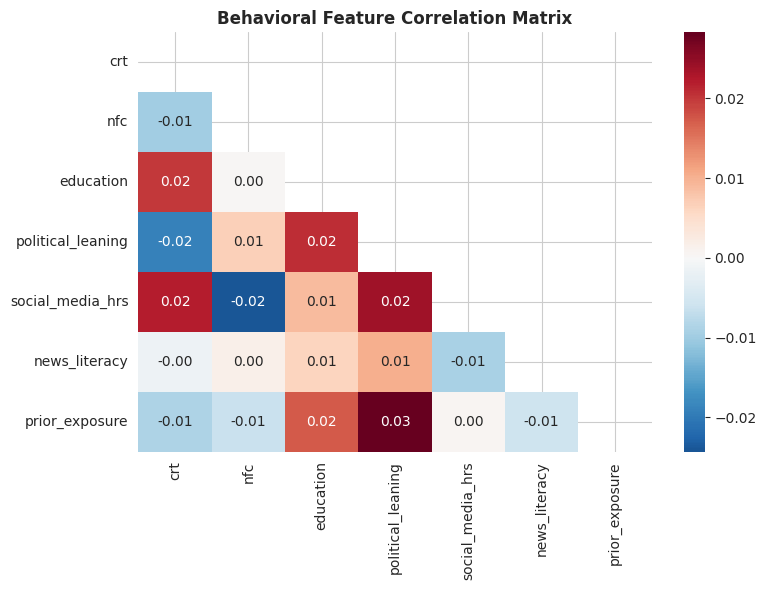

['/workspaces/tentacles-of-misinformation/models/behavioral_scaler.joblib']

In [3]:
def generate_behavioral_features(n, seed=42):
    rng = np.random.default_rng(seed)
    return pd.DataFrame({
        'crt':              np.clip(rng.normal(3.2, 1.8, n).round(), 0, 7).astype(int),
        'nfc':              np.clip(rng.normal(3.4, 0.7, n), 1, 5).round(2),
        'education':        rng.choice([1,2,3,4,5], n, p=[0.05,0.10,0.40,0.30,0.15]),
        'political_leaning':np.clip(rng.normal(4.0, 1.5, n).round(), 1, 7).astype(int),
        'social_media_hrs': np.clip(rng.exponential(2.5, n), 0, 12).round(2),
        'news_literacy':    np.clip(rng.normal(3.1, 0.9, n), 1, 5).round(2),
        'prior_exposure':   rng.beta(2, 5, n).round(3),
    })

df_behavioral = generate_behavioral_features(len(df_articles))
beh_train = df_behavioral.iloc[:len(train_art)].reset_index(drop=True)
beh_val   = df_behavioral.iloc[len(train_art):len(train_art)+len(val_art)].reset_index(drop=True)

scaler = StandardScaler()
X_beh_train = scaler.fit_transform(beh_train)
X_beh_val   = scaler.transform(beh_val)
print(f'Behavioral features: {X_beh_train.shape} (train), {X_beh_val.shape} (val)')

fig, ax = plt.subplots(figsize=(8,6))
corr = beh_train.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax, mask=np.triu(np.ones_like(corr,bool)))
ax.set_title('Behavioral Feature Correlation Matrix', fontweight='bold')
plt.tight_layout(); plt.savefig(RESULTS_DIR/'behavioral_feature_correlations.png',dpi=150,bbox_inches='tight'); plt.show()
joblib.dump(scaler, MODEL_DIR/'behavioral_scaler.joblib')

## 4. NLP Feature Extraction

In [4]:
tfidf = TfidfVectorizer(stop_words='english', max_features=2000, ngram_range=(1,2), min_df=2, sublinear_tf=True)
X_tfidf_train = tfidf.fit_transform(train_art['title'])
X_tfidf_val   = tfidf.transform(val_art['title'])

sbert_train_p = MODEL_DIR / 'embeddings' / 'train_sbert.npy'
sbert_val_p   = MODEL_DIR / 'embeddings' / 'val_sbert.npy'

if sbert_train_p.exists() and sbert_val_p.exists():
    X_nlp_train = np.load(sbert_train_p)
    X_nlp_val   = np.load(sbert_val_p)
    NLP_TYPE = 'SBERT-384'
else:
    svd = TruncatedSVD(n_components=64, random_state=42)
    X_nlp_train = svd.fit_transform(X_tfidf_train)
    X_nlp_val   = svd.transform(X_tfidf_val)
    NLP_TYPE = 'TF-IDF+SVD-64'

y_train = train_art['label_num'].values
y_val   = val_art['label_num'].values
print(f'NLP features ({NLP_TYPE}): {X_nlp_train.shape}')

NLP features (SBERT-384): (2400, 384)


## 5. Cross-Modal Correlation Analysis

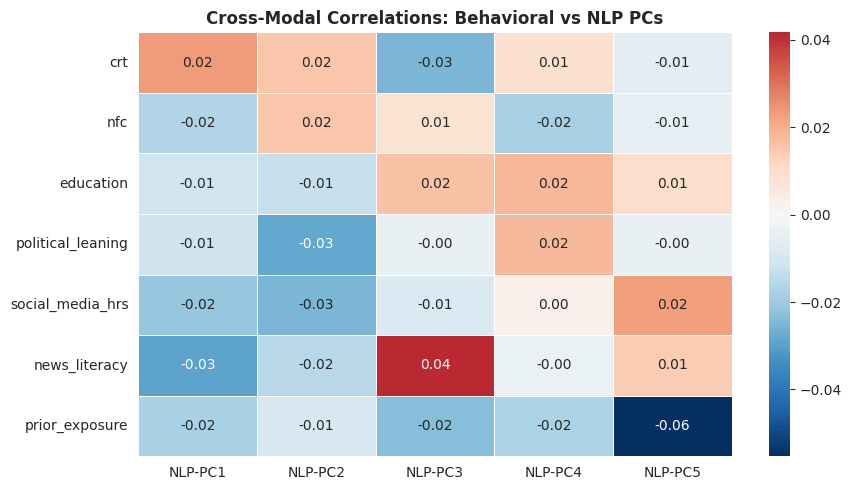

Cross-modal corr range: [-0.055, 0.042]
Low correlations indicate complementary modalities — fusion should help!


In [5]:
pca5 = PCA(n_components=5, random_state=42)
X_nlp_pca5 = pca5.fit_transform(X_nlp_train)
cross_corr = np.corrcoef(np.hstack([X_beh_train, X_nlp_pca5]).T)[:X_beh_train.shape[1], X_beh_train.shape[1]:]
cross_df = pd.DataFrame(cross_corr, index=beh_train.columns, columns=[f'NLP-PC{i+1}' for i in range(5)])

fig, ax = plt.subplots(figsize=(9,5))
sns.heatmap(cross_df, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax, linewidths=0.5)
ax.set_title('Cross-Modal Correlations: Behavioral vs NLP PCs', fontweight='bold')
plt.tight_layout(); plt.savefig(RESULTS_DIR/'cross_modal_correlations.png',dpi=150,bbox_inches='tight'); plt.show()
print(f'Cross-modal corr range: [{cross_corr.min():.3f}, {cross_corr.max():.3f}]')
print('Low correlations indicate complementary modalities — fusion should help!')

## 6. Build Aligned Fusion Matrices & Sanity Check

In [6]:
pca_beh = PCA(n_components=min(4, X_beh_train.shape[1]), random_state=42)
pca_nlp = PCA(n_components=min(32, X_nlp_train.shape[1]), random_state=42)
X_beh_pca_train = pca_beh.fit_transform(X_beh_train); X_beh_pca_val = pca_beh.transform(X_beh_val)
X_nlp_pca_train = pca_nlp.fit_transform(X_nlp_train); X_nlp_pca_val = pca_nlp.transform(X_nlp_val)

FUSION_CONFIGS = {
    'early_fusion':    (np.hstack([X_beh_train, X_nlp_train]), np.hstack([X_beh_val, X_nlp_val])),
    'behavioral_only': (X_beh_train, X_beh_val),
    'nlp_only':        (X_nlp_train, X_nlp_val),
    'intermediate':    (np.hstack([X_beh_pca_train,X_nlp_pca_train]), np.hstack([X_beh_pca_val,X_nlp_pca_val])),
}

print('Feature Alignment Summary')
print('='*65)
rows = []
for name,(Xtr,Xvl) in FUSION_CONFIGS.items():
    clf = LogisticRegression(C=1.0, max_iter=500, random_state=42, class_weight='balanced')
    clf.fit(Xtr, y_train)
    auc_v = roc_auc_score(y_val, clf.predict_proba(Xvl)[:,1])
    rows.append({'Strategy':name,'Train':str(Xtr.shape),'Val':str(Xvl.shape),'Quick AUC':round(auc_v,4)})
    print(f'  {name:<22}  {str(Xtr.shape):<18}  AUC={auc_v:.4f}')

pd.DataFrame(rows).to_csv(FUSION_DIR/'01_feature_alignment_report.csv', index=False)

for fname, arr in [('X_beh_train',X_beh_train),('X_beh_val',X_beh_val),
                    ('X_nlp_train',X_nlp_train),('X_nlp_val',X_nlp_val),
                    ('y_train',y_train),('y_val',y_val)]:
    np.save(MODEL_DIR / f'{fname}.npy', arr)
joblib.dump(pca_beh, MODEL_DIR/'pca_behavioral.joblib')
joblib.dump(pca_nlp, MODEL_DIR/'pca_nlp.joblib')
print('\nAll matrices saved. Next: 02_fusion_architectures.ipynb')

Feature Alignment Summary


  early_fusion            (2400, 391)         AUC=1.0000
  behavioral_only         (2400, 7)           AUC=0.4738


  nlp_only                (2400, 384)         AUC=1.0000


  intermediate            (2400, 36)          AUC=1.0000

All matrices saved. Next: 02_fusion_architectures.ipynb
